# Track1 Encoder: DeBERTa-v2-XXLarge + LoRA + R-Drop

This notebook upgrades the BERT R-Drop experiment to `microsoft/deberta-v2-xxlarge`. It uses LoRA for single-GPU 24GB training, weighted CE for class imbalance, label smoothing for regularization, and a batch-normalized symmetric KL R-Drop loss.


In [1]:
!nvidia-smi


Wed Jun 10 19:17:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.02              Driver Version: 555.42.02      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:01:00.0 Off |                  N/A |
|  0%   59C    P0            128W /  350W |       1MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "60"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "600"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("HF_ENDPOINT:", os.environ.get("HF_ENDPOINT"))
print("HF_HUB_DISABLE_XET:", os.environ.get("HF_HUB_DISABLE_XET"))


HF_ENDPOINT: https://hf-mirror.com
HF_HUB_DISABLE_XET: 1


In [3]:
import os

MODEL_NAME = "microsoft/deberta-v2-xxlarge"
DATA_DIR = "/home/yangdejin/nlpcc/nlpcc_task2/data"
OUTPUT_DIR = "/home/yangdejin/nlpcc/nlpcc_task2/outputs/track1/encoder/deberta_v2_xxlarge_lora_rdrop"
LOGGING_DIR = "/home/yangdejin/nlpcc/nlpcc_task2/logs/deberta_v2_xxlarge_lora_rdrop"

MAX_LENGTH = 512
NUM_EPOCHS = 8
LR = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
LOGGING_STEPS = 20
SEED = 3407

# R-Drop runs two forward passes during training, so start lower than plain LoRA.
# If peak_reserved is still far below 24GB, try 48 or 64.
TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE = 64
GRADIENT_ACCUMULATION_STEPS = 1
AUTO_FIND_BATCH_SIZE = True

# LoRA keeps xxlarge trainable on one 24GB GPU.
LORA_R = 32
LORA_ALPHA = 64
LORA_DROPOUT = 0.05
LORA_TARGET_MODULES = ["query_proj", "key_proj", "value_proj", "dense"]
MODULES_TO_SAVE = ["classifier", "pooler"]

# Regularization knobs.
RDROP_ALPHA = 1.0
LABEL_SMOOTHING = 0.03
DROPOUT_OVERRIDE = 0.15

TRAIN_CONTEXT_MODE = "response_only"
EVAL_CONTEXT_MODE = "response_only"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOGGING_DIR, exist_ok=True)

print(f"Model : {MODEL_NAME}")
print(f"Output: {OUTPUT_DIR}")
print(f"Train batch size: {TRAIN_BATCH_SIZE}")
print(f"Eval batch size : {EVAL_BATCH_SIZE}")
print(f"Effective train batch size: {TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"LoRA r/alpha: {LORA_R}/{LORA_ALPHA}")
print(f"R-Drop alpha: {RDROP_ALPHA}, label smoothing: {LABEL_SMOOTHING}")


Model : microsoft/deberta-v2-xxlarge
Output: /home/yangdejin/nlpcc/nlpcc_task2/outputs/track1/encoder/deberta_v2_xxlarge_lora_rdrop
Train batch size: 32
Eval batch size : 64
Effective train batch size: 32
LoRA r/alpha: 32/64
R-Drop alpha: 1.0, label smoothing: 0.03


In [4]:
import json
from collections import Counter

VALUE_LABELS = [
    "Self-direction–thought",
    "Self-direction–action",
    "Stimulation",
    "Hedonism",
    "Achievement",
    "Power–dominance",
    "Power–resources",
    "Face",
    "Security–personal",
    "Security–societal",
    "Tradition",
    "Conformity–rules",
    "Conformity–interpersonal",
    "Humility",
    "Benevolence–dependability",
    "Benevolence–caring",
    "Universalism–concern",
    "Universalism–nature",
    "Universalism–tolerance",
]

NUM_CLASSES = len(VALUE_LABELS)
label2id = {v: i for i, v in enumerate(VALUE_LABELS)}
id2label = {i: v for i, v in enumerate(VALUE_LABELS)}

print(f"Number of classes: {NUM_CLASSES}")

train_vals = []
with open(os.path.join(DATA_DIR, "train.jsonl")) as f:
    for line in f:
        train_vals.append(json.loads(line)["Value"])

counter = Counter(train_vals)
print("\nTrain class distribution:")
for label in VALUE_LABELS:
    print(f"  {label:<40s}: {counter[label]}")


Number of classes: 19

Train class distribution:
  Self-direction–thought                  : 119
  Self-direction–action                   : 124
  Stimulation                             : 400
  Hedonism                                : 164
  Achievement                             : 174
  Power–dominance                         : 156
  Power–resources                         : 237
  Face                                    : 258
  Security–personal                       : 202
  Security–societal                       : 70
  Tradition                               : 90
  Conformity–rules                        : 385
  Conformity–interpersonal                : 236
  Humility                                : 100
  Benevolence–dependability               : 189
  Benevolence–caring                      : 317
  Universalism–concern                    : 160
  Universalism–nature                     : 71
  Universalism–tolerance                  : 68


In [5]:
import json
import random
import numpy as np
from datasets import Dataset


def build_text(row, context_mode="response_only"):
    response = str(row.get("Consistent Value Response", "")).strip()
    scenario = str(row.get("Scenario", "")).strip()
    question = str(row.get("Question", "")).strip()

    if context_mode == "response_only":
        return "Response: " + response
    if context_mode == "question_response":
        return "Question: " + question + " [SEP] Response: " + response
    if context_mode == "scenario_response":
        return "Scenario: " + scenario + " [SEP] Response: " + response
    if context_mode == "full_context":
        parts = []
        if scenario:
            parts.append("Scenario: " + scenario)
        if question:
            parts.append("Question: " + question)
        if response:
            parts.append("Response: " + response)
        return " [SEP] ".join(parts)
    if context_mode == "context_dropout":
        modes = ["response_only", "question_response", "scenario_response", "full_context"]
        return build_text(row, random.choice(modes))
    raise ValueError(f"Unknown context_mode: {context_mode}")


def load_jsonl(path, has_label=True, context_mode="response_only"):
    texts, labels = [], []
    with open(path) as f:
        for line in f:
            row = json.loads(line)
            texts.append(build_text(row, context_mode))
            if has_label:
                labels.append(label2id[row["Value"]])
    if has_label:
        return Dataset.from_dict({"text": texts, "label": labels})
    return Dataset.from_dict({"text": texts})


random.seed(SEED)
train_dataset = load_jsonl(os.path.join(DATA_DIR, "train.jsonl"), context_mode=TRAIN_CONTEXT_MODE)
dev_dataset = load_jsonl(os.path.join(DATA_DIR, "dev.jsonl"), context_mode=EVAL_CONTEXT_MODE)

print(f"Train size : {len(train_dataset)}")
print(f"Dev size   : {len(dev_dataset)}")
print(f"\nTrain sample text:\n{train_dataset[0]['text'][:300]}")
print(f"\nDev sample text:\n{dev_dataset[0]['text'][:300]}")


Train size : 3520
Dev size   : 514

Train sample text:
Response: I would suggest alternative solutions diplomatically, ensuring my input is heard without challenging the manager openly, prioritizing team harmony and respect for hierarchy.

Dev sample text:
Response: I would prioritize maintaining that frequent contact despite my schedule, as I want to ensure my teammate feels valued, included, and that our teamwork remains perfectly smooth.


In [6]:
import torch


def print_gpu_memory(stage):
    if not torch.cuda.is_available():
        return
    torch.cuda.synchronize()
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    peak_allocated = torch.cuda.max_memory_allocated() / 1024**3
    peak_reserved = torch.cuda.max_memory_reserved() / 1024**3
    print(
        f"[{stage}] allocated={allocated:.2f} GB | reserved={reserved:.2f} GB | "
        f"peak_allocated={peak_allocated:.2f} GB | peak_reserved={peak_reserved:.2f} GB"
    )


if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    print_gpu_memory("notebook start")


[notebook start] allocated=0.00 GB | reserved=0.00 GB | peak_allocated=0.00 GB | peak_reserved=0.00 GB


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoConfig, AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding
from transformers.modeling_outputs import SequenceClassifierOutput
from peft import LoraConfig, TaskType, get_peft_model

train_labels_np = np.array(train_dataset["label"])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels_np,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", np.round(class_weights, 3))


def symmetric_kl_loss(logits_a, logits_b):
    log_probs_a = F.log_softmax(logits_a.float(), dim=-1)
    log_probs_b = F.log_softmax(logits_b.float(), dim=-1)
    probs_a = log_probs_a.exp()
    probs_b = log_probs_b.exp()
    kl_ab = F.kl_div(log_probs_a, probs_b, reduction="batchmean")
    kl_ba = F.kl_div(log_probs_b, probs_a, reduction="batchmean")
    return 0.5 * (kl_ab + kl_ba)


class DebertaRDropClassifier(nn.Module):
    def __init__(self, model_name, num_labels, class_weights):
        super().__init__()
        self.num_labels = num_labels
        self.rdrop_alpha = RDROP_ALPHA

        if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
            dtype = torch.bfloat16
        elif torch.cuda.is_available():
            dtype = torch.float16
        else:
            dtype = torch.float32

        config = AutoConfig.from_pretrained(
            model_name,
            num_labels=num_labels,
            id2label=id2label,
            label2id=label2id,
        )
        config.hidden_dropout_prob = DROPOUT_OVERRIDE
        config.attention_probs_dropout_prob = DROPOUT_OVERRIDE
        config.classifier_dropout = DROPOUT_OVERRIDE

        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            config=config,
            torch_dtype=dtype,
        )
        lora_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=LORA_R,
            lora_alpha=LORA_ALPHA,
            lora_dropout=LORA_DROPOUT,
            target_modules=LORA_TARGET_MODULES,
            modules_to_save=MODULES_TO_SAVE,
            bias="none",
        )
        self.model = get_peft_model(self.model, lora_config)
        if hasattr(self.model, "gradient_checkpointing_enable"):
            self.model.gradient_checkpointing_enable()
        if hasattr(self.model, "enable_input_require_grads"):
            self.model.enable_input_require_grads()

        self.register_buffer("class_weights", class_weights.clone().float())

    def _forward_logits(self, input_ids=None, attention_mask=None, token_type_ids=None, **kwargs):
        model_kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None:
            model_kwargs["token_type_ids"] = token_type_ids
        outputs = self.model(**model_kwargs)
        return outputs.logits

    def _weighted_ce(self, logits, labels):
        return F.cross_entropy(
            logits.float(),
            labels.view(-1),
            weight=self.class_weights.to(logits.device),
            label_smoothing=LABEL_SMOOTHING,
        )

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, labels=None, **kwargs):
        logits = self._forward_logits(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )

        loss = None
        if labels is not None:
            ce_loss = self._weighted_ce(logits, labels)
            loss = ce_loss

            if self.training and self.rdrop_alpha > 0:
                logits_2 = self._forward_logits(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    token_type_ids=token_type_ids,
                )
                ce_loss_2 = self._weighted_ce(logits_2, labels)
                kl_loss = symmetric_kl_loss(logits, logits_2)
                loss = 0.5 * (ce_loss + ce_loss_2) + self.rdrop_alpha * kl_loss
                logits = 0.5 * (logits + logits_2)

        return SequenceClassifierOutput(loss=loss, logits=logits)


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)


def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LENGTH)


train_dataset = train_dataset.map(tokenize_fn, batched=True)
dev_dataset = dev_dataset.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
model = DebertaRDropClassifier(MODEL_NAME, NUM_CLASSES, class_weights_tensor)
model.model.print_trainable_parameters()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100 * trainable_params / total_params:.4f}%)")
print_gpu_memory("after model build")


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Class weights: [1.557 1.494 0.463 1.13  1.065 1.188 0.782 0.718 0.917 2.647 2.058 0.481
 0.785 1.853 0.98  0.584 1.158 2.609 2.724]


Map:   0%|          | 0/3520 [00:00<?, ? examples/s]

Map:   0%|          | 0/514 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/778 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v2-xxlarge
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 44,857,363 || all params: 1,611,797,030 || trainable%: 2.7831
Total parameters: 1,611,797,030
Trainable parameters: 44,857,363 (2.7831%)
[after model build] allocated=0.00 GB | reserved=0.00 GB | peak_allocated=0.00 GB | peak_reserved=0.00 GB


In [8]:
import inspect
import evaluate
import numpy as np
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "macro_f1": f1}


training_kwargs = dict(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LR,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    logging_dir=LOGGING_DIR,
    logging_steps=LOGGING_STEPS,
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    seed=SEED,
    report_to="none",
    fp16=torch.cuda.is_available() and not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    optim="adamw_torch",
    lr_scheduler_type="linear",
    label_names=["labels"],
)

signature = inspect.signature(TrainingArguments.__init__).parameters
if "eval_strategy" in signature:
    training_kwargs["eval_strategy"] = "epoch"
else:
    training_kwargs["evaluation_strategy"] = "epoch"
if "auto_find_batch_size" in signature:
    training_kwargs["auto_find_batch_size"] = AUTO_FIND_BATCH_SIZE

training_args = TrainingArguments(**training_kwargs)

trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
trainer_signature = inspect.signature(Trainer.__init__).parameters
if "processing_class" in trainer_signature:
    trainer_kwargs["processing_class"] = tokenizer
else:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = Trainer(**trainer_kwargs)

print_gpu_memory("before train")
trainer_stats = trainer.train()
print(trainer_stats)
print_gpu_memory("after train")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


[before train] allocated=3.08 GB | reserved=3.20 GB | peak_allocated=3.08 GB | peak_reserved=3.20 GB


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,3.006559,2.984942,0.112840,0.010674
2,3.004256,2.979122,0.083658,0.024403
3,2.992473,2.973718,0.077821,0.042528
4,2.714372,2.427936,0.303502,0.239673
5,1.747811,1.288199,0.745136,0.700976
6,1.110417,0.815523,0.857977,0.840173
7,0.848332,0.675829,0.875486,0.861929
8,0.803006,0.640401,0.877432,0.862154


TrainOutput(global_step=880, training_loss=2.1211132168769837, metrics={'train_runtime': 1321.3424, 'train_samples_per_second': 21.312, 'train_steps_per_second': 0.666, 'total_flos': 0.0, 'train_loss': 2.1211132168769837, 'epoch': 8.0})
[after train] allocated=3.43 GB | reserved=7.42 GB | peak_allocated=6.54 GB | peak_reserved=7.42 GB


Dev Set Evaluation Results — DeBERTa-v2-XXLarge LoRA R-Drop
                           precision    recall  f1-score   support

   Self-direction–thought     0.6087    0.8235    0.7000        17
    Self-direction–action     0.6190    0.7222    0.6667        18
              Stimulation     1.0000    0.9483    0.9735        58
                 Hedonism     0.9231    1.0000    0.9600        24
              Achievement     0.8800    0.8462    0.8627        26
          Power–dominance     0.9167    0.9565    0.9362        23
          Power–resources     0.9706    0.9429    0.9565        35
                     Face     0.8974    0.9459    0.9211        37
        Security–personal     0.9630    0.8966    0.9286        29
        Security–societal     0.7692    0.9091    0.8333        11
                Tradition     0.9333    1.0000    0.9655        14
         Conformity–rules     0.9608    0.8909    0.9245        55
 Conformity–interpersonal     0.8333    0.5882    0.6897        34
 

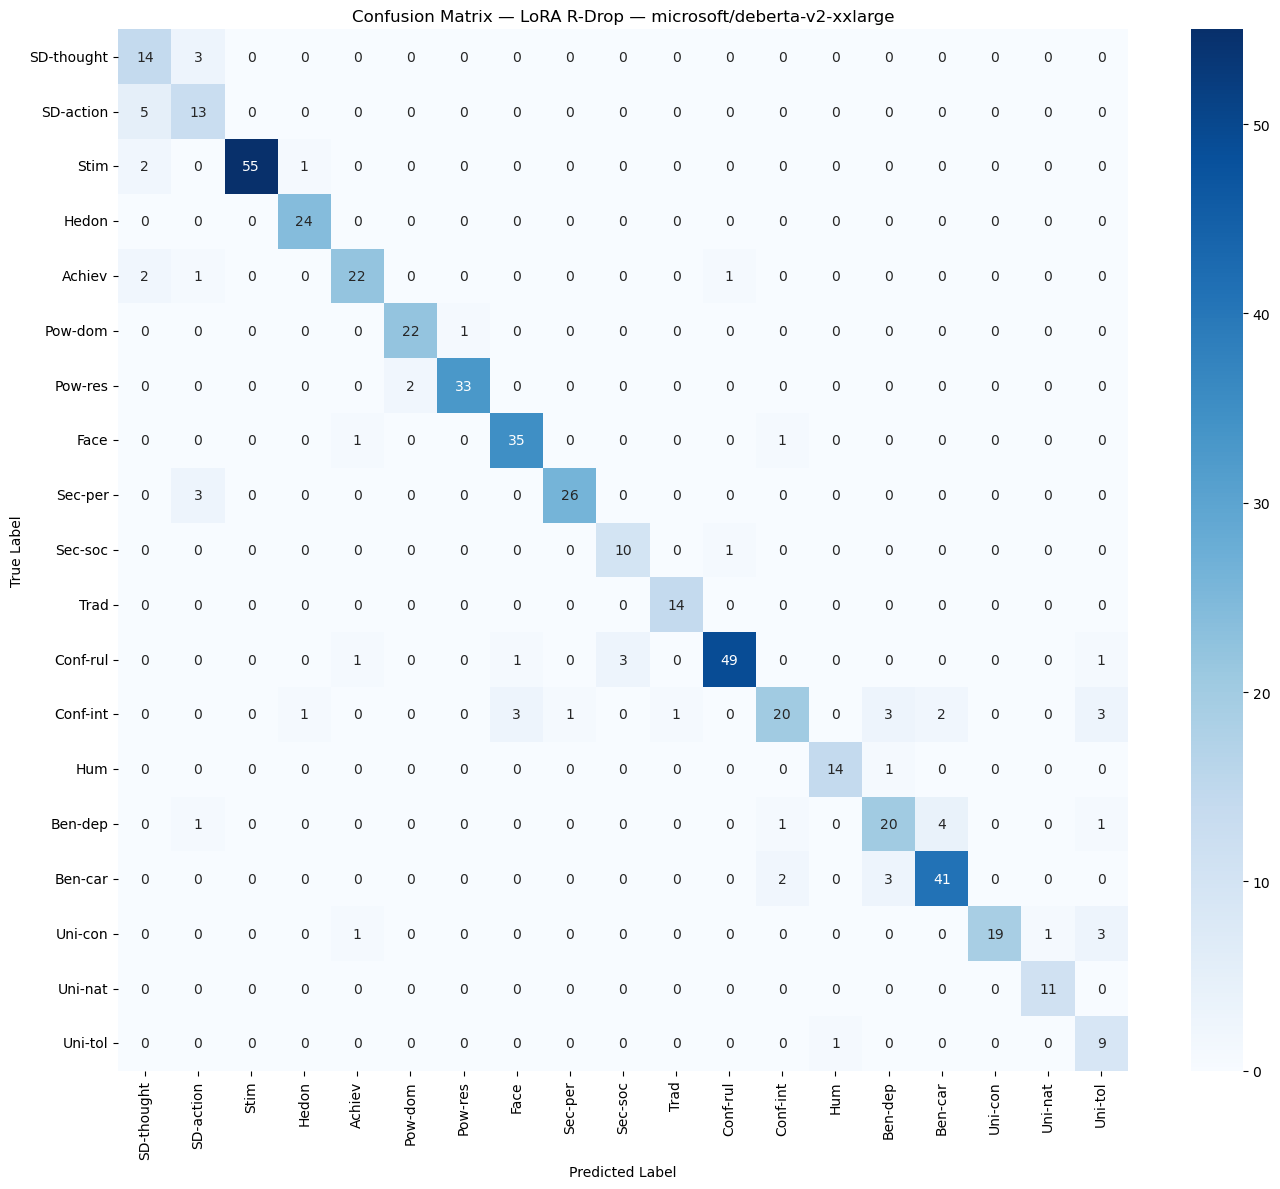

Confusion matrix saved to /home/yangdejin/nlpcc/nlpcc_task2/outputs/track1/encoder/deberta_v2_xxlarge_lora_rdrop/confusion_matrix.png


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

pred_output = trainer.predict(dev_dataset)
preds = np.argmax(pred_output.predictions, axis=-1)
labels = np.array(dev_dataset["label"])

print("=" * 60)
print("Dev Set Evaluation Results — DeBERTa-v2-XXLarge LoRA R-Drop")
print("=" * 60)
print(classification_report(
    labels,
    preds,
    target_names=VALUE_LABELS,
    digits=4,
))

cm = confusion_matrix(labels, preds)
short_labels = [
    "SD-thought", "SD-action", "Stim", "Hedon", "Achiev",
    "Pow-dom", "Pow-res", "Face", "Sec-per", "Sec-soc",
    "Trad", "Conf-rul", "Conf-int", "Hum", "Ben-dep",
    "Ben-car", "Uni-con", "Uni-nat", "Uni-tol",
]

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=short_labels,
    yticklabels=short_labels,
)
plt.title(f"Confusion Matrix — LoRA R-Drop — {MODEL_NAME}")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()
print(f"Confusion matrix saved to {OUTPUT_DIR}/confusion_matrix.png")


In [10]:
compact_dir = os.path.join(OUTPUT_DIR, "compact_adapter")
os.makedirs(compact_dir, exist_ok=True)
model.model.save_pretrained(os.path.join(compact_dir, "model_lora"))
tokenizer.save_pretrained(compact_dir)
torch.save(
    {
        "id2label": id2label,
        "label2id": label2id,
        "model_name": MODEL_NAME,
        "rdrop_alpha": RDROP_ALPHA,
        "label_smoothing": LABEL_SMOOTHING,
        "dropout_override": DROPOUT_OVERRIDE,
    },
    os.path.join(compact_dir, "metadata.pt"),
)
print(f"Compact adapter saved to {compact_dir}")


Compact adapter saved to /home/yangdejin/nlpcc/nlpcc_task2/outputs/track1/encoder/deberta_v2_xxlarge_lora_rdrop/compact_adapter
